### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## LangChain v1 Agents: Complete Guide

## Prerequisites

Make sure you have the required packages installed and Ollama running:

```bash
pip install -U langchain langchain-community langchain-core langgraph
pip install -U ddgs python-dotenv
```

Local LLM Serving with Ollama:
```bash
ollama pull qwen3
ollama pull gemma3
```

In [2]:
# pip install -U langchain langchain-community langchain-core langgraph
# pip install -U ddgs python-dotenv

---
## 1. Agent with Explicit Model Instance

Full control over model configuration by creating an explicit ChatOllama instance.

## Model Parameters Explained
- **temperature**: Controls randomness (0.0 = deterministic, 1.0 = very creative)
- **num_predict**: Maximum tokens to generate (similar to max_tokens in OpenAI)
- **top_k**: Number of highest probability tokens to consider
- **top_p**: Cumulative probability threshold for token selection
- **repeat_penalty**: Penalty for repeating tokens
- **num_ctx**: Context window size

In [3]:
from langchain_ollama import ChatOllama
from langchain.agents import create_agent
from langfuse.langchain import CallbackHandler
import tools

langfuce_trace = CallbackHandler()

In [4]:
system_prompt = """You are a helpful AI assistant. 
Use the available tools when needed to answer questions accurately.
If you need to search for information, use the web_search tool.
Always provide clear and concise answers.
"""

In [5]:
print(tools.web_search.invoke({"query": "What is Langchain?", "num_results": 1}))
# print(tools.web_search.invoke({"query": "Python programming", "num_results": 1}))

Search Results for 'What is Langchain?':


1. **Langchain**
   11 hours ago - This post goes into the technical details of how we built it: why we built Engine, what inputs and outputs it works with, and the architecture decisions that let it analyze large volumes of traces. LangSmith is the home of the agent improvement loop.
   https://www.langchain.com/blog/how-we-built-langsmith-engine-our-agent-for-improving-agents


### Your First Agent

In [ ]:
# model = ChatOllama(model="qwen3", base_url="http://localhost:11434")
model = ChatOllama(model="qwen3:4b", base_url="http://localhost:11434")

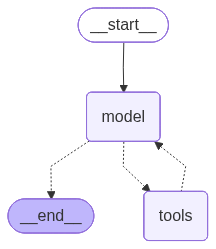

In [7]:
agent = create_agent(model=model, tools=[tools.web_search], system_prompt=system_prompt)
agent

In [8]:
result = agent.invoke({"messages": "What is the top 10 global news right now?"}, config={"callbacks": [langfuce_trace]})

In [9]:
result

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='bb20a996-8acf-4169-9a63-54db582f6b42'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-05-29T10:18:13.035080341Z', 'done': True, 'done_reason': 'stop', 'total_duration': 56488190177, 'load_duration': 11272904613, 'prompt_eval_count': 247, 'prompt_eval_duration': 6819662809, 'eval_count': 438, 'eval_duration': 38055301651, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--019e733c-fa00-7d02-b194-8b0ea87d3037-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news right now', 'num_results': 10}, 'id': 'c1c3d9f3-6fd1-4abe-9158-481545a570b3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens': 438, 'total_tokens': 685}),
  ToolMessage(content="Search Results for 'top 10 global news right now':\n\n\n1. **

In [10]:
print(result['messages'])

[HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='bb20a996-8acf-4169-9a63-54db582f6b42'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-05-29T10:18:13.035080341Z', 'done': True, 'done_reason': 'stop', 'total_duration': 56488190177, 'load_duration': 11272904613, 'prompt_eval_count': 247, 'prompt_eval_duration': 6819662809, 'eval_count': 438, 'eval_duration': 38055301651, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--019e733c-fa00-7d02-b194-8b0ea87d3037-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news right now', 'num_results': 10}, 'id': 'c1c3d9f3-6fd1-4abe-9158-481545a570b3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens': 438, 'total_tokens': 685}), ToolMessage(content="Search Results for 'top 10 global news right now':\n\n\n1. **Breaking and Late

In [11]:
print(result['messages'][-1].content) # Access result from AIMessage class output

Based on the latest search results for global news (as of the most recent data), here are the **top 10 headlines** reflecting current events. Note that some sources have specific details, while others highlight broader trends or breaking news. The list prioritizes verifiable, time-sensitive stories from credible outlets:

---

### 🌍 Top 10 Global News Headlines (Latest Updates)
1. **Netanyahu warns Gaza fighting will resume if hostages are not released** (The Sentinel)  
   *Breaking update: Israeli leader states that intensified clashes in Gaza could escalate if Hamas hostages are not freed.*

2. **Iran and U.S. trade attacks after Trump rejects Hormuz agreement** (Al Jazeera)  
   *Geopolitical tension rises as regional security talks collapse following U.S. rejection of a proposed deal.*

3. **U.S. Supreme Court sides with death row inmate who claimed racial bias in jury selection** (USNews)  
   *Ruling highlights ongoing legal challenges related to jury impartiality and systemic r

In [12]:

result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Based on the latest search results for global news (as of the most recent data), here are the **top 10 headlines** reflecting current events. Note that some sources have specific details, while others highlight broader trends or breaking news. The list prioritizes verifiable, time-sensitive stories from credible outlets:

---

### 🌍 Top 10 Global News Headlines (Latest Updates)
1. **Netanyahu warns Gaza fighting will resume if hostages are not released** (The Sentinel)  
   *Breaking update: Israeli leader states that intensified clashes in Gaza could escalate if Hamas hostages are not freed.*

2. **Iran and U.S. trade attacks after Trump rejects Hormuz agreement** (Al Jazeera)  
   *Geopolitical tension rises as regional security talks collapse following U.S. rejection of a proposed deal.*

3. **U.S. Supreme Court sides with death row inmate who claimed racial bias in jury selection** (USNews)  
   *Ruli

In [13]:
result1 = agent.invoke(result, config={"callbacks": [langfuce_trace]})

In [14]:
result1

{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='bb20a996-8acf-4169-9a63-54db582f6b42'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-05-29T10:18:13.035080341Z', 'done': True, 'done_reason': 'stop', 'total_duration': 56488190177, 'load_duration': 11272904613, 'prompt_eval_count': 247, 'prompt_eval_duration': 6819662809, 'eval_count': 438, 'eval_duration': 38055301651, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--019e733c-fa00-7d02-b194-8b0ea87d3037-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news right now', 'num_results': 10}, 'id': 'c1c3d9f3-6fd1-4abe-9158-481545a570b3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens': 438, 'total_tokens': 685}),
  ToolMessage(content="Search Results for 'top 10 global news right now':\n\n\n1. **

### Experimenting with Different Settings

Let's compare different model configurations to see how they affect the output:

In [ ]:
question = "What is the capital of France? Provide a brief explanation."

# model1 = ChatOllama(model="qwen3", base_url="http://localhost:11434",
model1 = ChatOllama(model="qwen3:4b", base_url="http://localhost:11434",
                    temperature=0,
                    top_p=1,
                    repeart_penalty=1.2,
                    num_predict=1000,
                    num_ctx=4096,
                    reasoning=True)

agent1 = create_agent(model=model1, tools=[tools.web_search], system_prompt=system_prompt)
result1 = agent1.invoke({"messages": question}, config={"callbacks": [langfuce_trace]})

In [16]:
result1

{'messages': [HumanMessage(content='What is the capital of France? Provide a brief explanation.', additional_kwargs={}, response_metadata={}, id='85ac24c8-7abd-4d46-99c0-8c9f6959cf65'),
  AIMessage(content='The capital of France is **Paris**. Paris is not only the political and cultural heart of France but also a major global city known for its landmarks like the Eiffel Tower, Louvre Museum, and historic architecture. It serves as the seat of the French government and is a hub for art, fashion, and commerce.', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the capital of France and a brief explanation. Let me start by recalling what I know. France is a country in Europe, and I believe the capital is Paris. But wait, I should make sure this information is up-to-date. Maybe there\'s a possibility of a change, though that\'s unlikely. To confirm, I can use the web_search tool. Let me check the function parameters. The tool requires a query and num_results. The query

## 2. Dynamic Model Selection (Qwen3 → Gemma3)

Cost-optimization strategy where the agent automatically switches between models based on conversation complexity.

## Selection Logic
- **< 10 messages**: Use Qwen3 (fast, efficient)
- **≥ 10 messages**: Use Gemma3 (better reasoning, longer context)

## Real-World Applications
- Customer service bots (simple queries → Qwen3, complex issues → Gemma3)
- Research assistants (quick facts → Qwen3, analysis → Gemma3)

In [17]:
# Import required modules
from langchain_ollama import ChatOllama
from langchain.agents import create_agent, AgentState
from langgraph.runtime import Runtime
import tools

# Import the middleware decorator
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse


In [18]:
basic_model = ChatOllama(model="qwen3:4b", base_url="http://localhost:11434", num_predict=1000)
advanced_model = ChatOllama(model="llama3.2", base_url="http://localhost:11434", num_predict=1000)

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    message_count = len(request.state["messages"])
    if message_count<3:
        print(f"Using Qwen3 for {message_count} messages")
        request.model = basic_model
    else:
        print(f"Using llama3.2 for {message_count} messages")
        request.model = advanced_model

    return handler(request)

In [19]:
agent = create_agent(model=basic_model,
                     tools = [tools.web_search],
                     system_prompt=system_prompt,
                     middleware=[dynamic_model_selection])

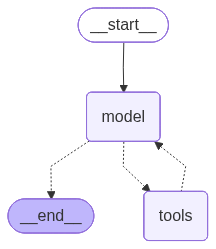

In [20]:
agent

In [21]:
def get_agent_output(messages:list):
    messages = {'messages': messages} # dict

    result = agent.invoke(messages, config={"callbacks": [langfuce_trace]})

    return result

In [22]:
messages = ["How are you?", "What's the weather in Mumbai today?,", "Explain machine learning"]
# result = get_agent_output(messages)

In [23]:
result


{'messages': [HumanMessage(content='What is the top 10 global news right now?', additional_kwargs={}, response_metadata={}, id='bb20a996-8acf-4169-9a63-54db582f6b42'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:4b', 'created_at': '2026-05-29T10:18:13.035080341Z', 'done': True, 'done_reason': 'stop', 'total_duration': 56488190177, 'load_duration': 11272904613, 'prompt_eval_count': 247, 'prompt_eval_duration': 6819662809, 'eval_count': 438, 'eval_duration': 38055301651, 'logprobs': None, 'model_name': 'qwen3:4b', 'model_provider': 'ollama'}, id='lc_run--019e733c-fa00-7d02-b194-8b0ea87d3037-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'top 10 global news right now', 'num_results': 10}, 'id': 'c1c3d9f3-6fd1-4abe-9158-481545a570b3', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 247, 'output_tokens': 438, 'total_tokens': 685}),
  ToolMessage(content="Search Results for 'top 10 global news right now':\n\n\n1. **

### Streaming Agent Responses
#### Stream Modes
- "values": Get complete state at each step
- "updates": Get only the changes/updates
- "messages": Get only message updates

In [24]:
messages

['How are you?',
 "What's the weather in Mumbai today?,",
 'Explain machine learning']

In [25]:
for chunk in agent.stream({"messages": messages}, stream_mode="values"):
    print(chunk['messages'][-1].content, end='', flush=True)

    print("\n\n------")

Explain machine learning

------
Using llama3.2 for 3 messages


C:\Users\Tho Le\AppData\Local\Temp\ipykernel_28088\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model




------
Search Results for 'How are you?':


1. **How are you?**
   The All-Ukrainian mental health program "How are you?" is an initiative aimed at building a quality system of providing services in the field of psychosocial support and developing a culture of mental health care. The initiative was launched by Olena Zelenska, the First Lady of Ukraine, in May 2022.
   https://en.wikipedia.org/wiki/How_are_you?

2. **You (TV series) - Wikipedia**
   1 day ago - You is an American psychological thriller television series based on the books by Caroline Kepnes, developed by Greg Berlanti and Sera Gamble, and produced by Berlanti Productions, Alloy Entertainment, and A+E Studios in association with Warner Horizon Television, now Warner Bros.
   https://en.wikipedia.org/wiki/You_(TV_series)

3. **You (TV Series 2018–2025) - IMDb**
   1 day ago - You: Created by Greg Berlanti, Sera Gamble. With Penn Badgley, Victoria Pedretti, Charlotte Ritchie, Elizabeth Lail. He's the perfect man - until 

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_28088\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


Here are the answers to your questions:

**How are you?**

I'm doing well, thank you for asking! I'm a helpful AI assistant, and I'm here to provide information and answer questions to the best of my ability.

**What's the weather in Mumbai today?**

According to the latest weather forecast, the current temperature in Mumbai is 31.8°C with a feels-like temperature of 37°C. There is a chance of light rain or thundershowers in the evening or night. Please note that weather forecasts are subject to change and may not be accurate at the time of reading.

**Explain machine learning**

Machine learning is a branch of artificial intelligence (AI) that involves training algorithms to learn from data and improve over time, without being explicitly programmed to do so. The goal of machine learning is to enable machines to perform tasks that typically require human intelligence, such as pattern recognition, decision-making, and prediction.

There are several types of machine learning, including s

In [26]:
for chunk in agent.stream(
    {"messages": messages},
    config={"callbacks": [langfuce_trace]},
    stream_mode="updates",
):
    # print(chunk, end='', flush=True)
    if 'model' in chunk:
        chunk['model']['messages'][-1].pretty_print()
    if 'tools' in chunk:
        chunk['tools']['messages'][-1].pretty_print()
    else:
        print(chunk)
    print("\n\n------")

Using llama3.2 for 3 messages


C:\Users\Tho Le\AppData\Local\Temp\ipykernel_28088\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


================================== Ai Message ==================================
Tool Calls:
  web_search (2d919cea-c37b-4fe5-94bf-da8af0add4b2)
 Call ID: 2d919cea-c37b-4fe5-94bf-da8af0add4b2
  Args:
    query: machine learning explanation
    num_results: 10
{'model': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T10:32:49.593227252Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6334743066, 'load_duration': 1012991012, 'prompt_eval_count': 263, 'prompt_eval_duration': 3092000626, 'eval_count': 26, 'eval_duration': 2169496558, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e734b-1dfa-72b0-9b88-bf06018fff9b-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'machine learning explanation', 'num_results': '10'}, 'id': '2d919cea-c37b-4fe5-94bf-da8af0add4b2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 263, 'output_tokens': 

C:\Users\Tho Le\AppData\Local\Temp\ipykernel_28088\2338425097.py:12: DeprecationWarning: Direct attribute assignment to ModelRequest.model is deprecated. Use request.override(model=...) instead to create a new request with the modified attribute.
  request.model = advanced_model


================================== Ai Message ==================================

Machine learning is a branch of artificial intelligence (AI) in which systems learn from data to improve their performance over time, without being explicitly programmed. In traditional programming, developers write specific rules that the computer follows. However, machine learning algorithms process numbers rather than text, so the text must be converted to numbers.

Here's a step-by-step explanation of how machine learning works:

1. **Data collection**: A large dataset is collected and labeled with relevant information.
2. **Data preprocessing**: The data is cleaned, transformed, and prepared for training.
3. **Model selection**: A suitable algorithm is chosen based on the type of problem and data.
4. **Training**: The model is trained on the labeled data, allowing it to learn patterns and relationships.
5. **Evaluation**: The trained model is evaluated on a test dataset to assess its performance.
6. 